# Movie Recommendation System — KNN + Ranking Pipeline
**BINUS University — Machine Learning Final Project**  
**Team:** Michael Angelo, Rafhael Hyuga, Evan Satyadharma, Jessica Veronica

---

### Notebook goals
1. Load clean data + feature matrix from Drive (output of `01_preprocessing_eda.ipynb`)
2. **Stage 1 — KNN candidate generation**: find the N most similar movies to the user's taste profile
3. **Stage 2 — Random Forest ranker**: re-rank candidates by predicted like probability
4. **Baseline comparison**: beat a global popularity baseline (Precision@K)
5. Export `knn_model.pkl` and `rf_ranker.pkl` to Drive for the Streamlit app

## 0 — Imports & Drive mount

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import MinMaxScaler

# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

CANDIDATES = [
    '/content/drive/MyDrive/MovieML',
    '/content/drive/Shareddrives/MovieML',
    '/content/drive/MyDrive/Shortcuts/MovieML',
]
DRIVE_DIR = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DRIVE_DIR is None:
    matches = glob.glob('/content/drive/**/MovieML', recursive=True)
    DRIVE_DIR = matches[0] if matches else None
assert DRIVE_DIR, 'MovieML folder not found. Add a shortcut to My Drive.'

OUTPUT_DIR = os.path.join(DRIVE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLEAN_CSV = os.path.join(OUTPUT_DIR, 'movies_clean.csv')
FEAT_CSV  = os.path.join(OUTPUT_DIR, 'feature_matrix.csv')
KNN_PKL   = os.path.join(OUTPUT_DIR, 'knn_model.pkl')
RF_PKL    = os.path.join(OUTPUT_DIR, 'rf_ranker.pkl')
FEAT_PKL  = os.path.join(OUTPUT_DIR, 'feature_matrix.pkl')

CORAL  = '#D85A30'; PURPLE = '#534AB7'
GRAY   = '#888780'; AMBER  = '#EF9F27'
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Drive folder: {DRIVE_DIR}')
print('Imports OK.')

Mounted at /content/drive
Drive folder: /content/drive/MyDrive/MovieML
Imports OK.


## 1 — Load data

In [ ]:
df    = pd.read_csv(CLEAN_CSV, index_col='movie_id')
feat  = pd.read_csv(FEAT_CSV,  index_col='movie_id')

assert list(df.index) == list(feat.index), 'Index mismatch between clean CSV and feature matrix!'

print(f'Movies:         {len(df):>7,}')
print(f'Feature matrix: {feat.shape[0]:>7,} rows × {feat.shape[1]} cols')
print(f'Feature cols:   {feat.columns.tolist()}')
df.head(3)

Movies:          13,338
Feature matrix:  13,338 rows × 24 cols
Feature cols:   ['genre_drama', 'genre_comedy', 'genre_action', 'genre_thriller', 'genre_romance', 'genre_crime', 'genre_adventure', 'genre_animation', 'genre_fantasy', 'genre_family', 'genre_sci_fi', 'genre_mystery', 'genre_horror', 'genre_documentary', 'genre_biography', 'genre_history', 'genre_music', 'genre_sport', 'genre_war', 'genre_short', 'imdb_score_norm', 'hidden_gem_norm', 'runtime_norm', 'is_movie']


,Title,Genre,Tags,Director,Actors,Summary,IMDb Score,Hidden Gem Score,Runtime,View Rating,Release Date,Series or Movie,Languages,Poster
movie_id,,,,,,,,,,,,,,
0,Lets Fight Ghost,"Crime, Drama, Fantasy, Horror, Romance","Comedy Programmes,Romantic TV Comedies,Horror ...",Tomas Alfredson,"Kåre Hedebrant, Per Ragnar, Lina Leandersson, ...",A med student with a supernatural gift tries t...,7.9,4.3,< 30 minutes,R,12 Dec 2008,Series,"Swedish, Spanish",https://m.media-amazon.com/images/M/MV5BOWM4NT...
1,HOW TO BUILD A GIRL,Comedy,"Dramas,Comedies,Films Based on Books,British",Coky Giedroyc,"Paddy Considine, Cleo, Beanie Feldstein, Dónal...","When nerdy Johanna moves to London, things get...",5.8,7.0,1-2 hour,R,08 May 2020,Movie,English,https://m.media-amazon.com/images/M/MV5BZGUyN2...
2,Centigrade,"Drama, Thriller",Thrillers,Brendan Walsh,"Genesis Rodriguez, Vincent Piazza","Trapped in a frozen car during a blizzard, a p...",4.3,6.4,1-2 hour,Unrated,28 Aug 2020,Movie,English,https://m.media-amazon.com/images/M/MV5BODM2MD...


## 2 — Stage 1: KNN candidate generation

We use `NearestNeighbors` with **cosine similarity** — cosine is better than euclidean here  
because it measures the *angle* between feature vectors, not their magnitude.  
A short Action/Sci-Fi film and a long one should still be similar to each other.

In [ ]:
# ── Fit KNN on the full feature matrix ─────────────────────────────────────
N_CANDIDATES = 50   # retrieve top 50 candidates, then re-rank with RF

knn = NearestNeighbors(
    n_neighbors = N_CANDIDATES + 1,  # +1 because query movie itself is returned
    metric      = 'cosine',
    algorithm   = 'brute',            # brute is best for cosine on dense matrices
    n_jobs      = -1
)
knn.fit(feat.values)
print(f'KNN fitted on {feat.shape[0]:,} movies with {feat.shape[1]} features.')
print(f'Retrieving top {N_CANDIDATES} candidates per query.')

KNN fitted on 13,338 movies with 24 features.
Retrieving top 50 candidates per query.


In [ ]:
# ── User query vector builder ───────────────────────────────────────────────
# This is what the Streamlit app will call.
#
# Inputs:
#   liked_genres  — list of genre strings the user selected, e.g. ['Action','Sci-Fi']
#   liked_directors — list of director strings, e.g. ['Christopher Nolan']
#   watch_history — dict of {movie_title: star_rating (1-5)}
#
# Returns:
#   query_vec — numpy array of shape (n_features,)

GENRE_COLS = [c for c in feat.columns if c.startswith('genre_')]
GENRE_MAP  = {g.replace('genre_','').replace('_','-'): g for g in GENRE_COLS}
# Also map without hyphen for flexible matching
GENRE_MAP.update({g.replace('genre_','').replace('_',' '): g for g in GENRE_COLS})

def build_query_vector(liked_genres, watch_history, feat_df=feat, clean_df=df):
    """
    Build a weighted query vector from user preferences.

    liked_genres  : list[str]  — e.g. ['Action', 'Sci-Fi']
    watch_history : dict       — {title_substring: rating_1_to_5}
    """
    vec = np.zeros(len(feat_df.columns))
    col_index = {c: i for i, c in enumerate(feat_df.columns)}

    # ── 1. Genre preferences ─────────────────────────────────────────────
    for genre in liked_genres:
        key = genre.lower().replace('-','_').replace(' ','_')
        col = f'genre_{key}'
        if col in col_index:
            vec[col_index[col]] = 1.0   # genre weight = 1.0 (matches feature matrix)

    # ── 2. Watch history — blend liked movies' feature vectors ───────────
    liked_vecs   = []
    disliked_vecs = []
    for title, rating in watch_history.items():
        match = clean_df[clean_df['Title'].str.contains(title, case=False, na=False)]
        if match.empty:
            continue
        movie_vec = feat_df.loc[match.index[0]].values.astype(float)
        if rating >= 4:
            liked_vecs.append(movie_vec * (rating / 5.0))  # weight by rating
        else:
            disliked_vecs.append(movie_vec)

    if liked_vecs:
        history_signal = np.mean(liked_vecs, axis=0)
        vec = vec + history_signal * 0.6   # blend: 60% history, rest genre prefs

    if disliked_vecs:
        dislike_signal = np.mean(disliked_vecs, axis=0)
        vec = vec - dislike_signal * 0.3   # steer away from disliked patterns
        vec = np.clip(vec, 0, None)        # no negative values

    # Normalize to unit vector for cosine similarity
    norm = np.linalg.norm(vec)
    if norm > 0:
        vec = vec / norm

    return vec

print('build_query_vector() defined.')

build_query_vector() defined.


In [ ]:
# ── KNN retrieval function ──────────────────────────────────────────────────
def get_knn_candidates(query_vec, watched_titles=None, n=N_CANDIDATES,
                        knn_model=knn, feat_df=feat, clean_df=df):
    """
    Returns a DataFrame of n candidate movies, excluding already-watched titles.
    """
    distances, indices = knn_model.kneighbors([query_vec])
    distances = distances[0]
    indices   = indices[0]

    candidates = clean_df.iloc[indices].copy()
    candidates['cosine_distance'] = distances
    candidates['similarity']      = (1 - distances).round(4)

    # Exclude already-watched movies
    if watched_titles:
        pattern = '|'.join(watched_titles)
        candidates = candidates[
            ~candidates['Title'].str.contains(pattern, case=False, na=False)
        ]

    return candidates.head(n).reset_index()

print('get_knn_candidates() defined.')

get_knn_candidates() defined.


In [ ]:
# ── Quick smoke test ────────────────────────────────────────────────────────
test_vec = build_query_vector(
    liked_genres  = ['Action', 'Sci-Fi', 'Thriller'],
    watch_history = {'Inception': 5, 'Interstellar': 5, 'Ultraviolet': 2}
)

candidates = get_knn_candidates(
    query_vec     = test_vec,
    watched_titles = ['Inception', 'Interstellar', 'Ultraviolet']
)

print(f'Candidates retrieved: {len(candidates)}')
print(candidates[['Title','Genre','IMDb Score','Director','similarity']]
      .head(10).to_string(index=False))

Candidates retrieved: 50
              Title                    Genre  IMDb Score                     Director  similarity
               Vice Action, Sci-Fi, Thriller         4.2              Brian A. Miller      0.9553
            Skyline Action, Sci-Fi, Thriller         4.4  Greg Strause, Colin Strause      0.9548
           Geostorm Action, Sci-Fi, Thriller         5.3                  Dean Devlin      0.9531
2036 Origin Unknown Action, Sci-Fi, Thriller         4.4                Hasraf Dulull      0.9521
     Bleeding Steel Action, Sci-Fi, Thriller         5.2                    Leo Zhang      0.9519
              Gamer Action, Sci-Fi, Thriller         5.8 Mark Neveldine, Brian Taylor      0.9515
   24 Hours to Live Action, Sci-Fi, Thriller         5.8                   Brian Smrz      0.9507
               Push Action, Sci-Fi, Thriller         6.1                Paul McGuigan      0.9505
           Godzilla Action, Sci-Fi, Thriller         5.4              Roland Emmerich      0.

## 3 — Stage 2: Random Forest ranker

KNN retrieves similar movies but doesn't know whether *this user* will enjoy them.  
We train a `RandomForestClassifier` on the user's watch history to predict **Like (1) / Dislike (0)**  
for each candidate, then sort by the predicted probability.

> **Note on training data size**: in a real deployment each user has their own micro-model  
> trained on their personal history. For evaluation here we simulate a pooled dataset.

In [ ]:
# ── Simulate a labelled training set from watch history ─────────────────────
# Strategy: use IMDb Score as a proxy for ground-truth labels.
#   Score >= 7.0  → Liked   (1)
#   Score <  5.5  → Disliked (0)
#   Between       → dropped (ambiguous)

LIKE_THRESHOLD    = 7.0
DISLIKE_THRESHOLD = 5.5

liked_df    = df[df['IMDb Score'] >= LIKE_THRESHOLD]
disliked_df = df[df['IMDb Score'] <  DISLIKE_THRESHOLD]

# Balance the classes — sample equal numbers
n_sample = min(len(liked_df), len(disliked_df), 2000)
liked_sample    = liked_df.sample(n=n_sample, random_state=42)
disliked_sample = disliked_df.sample(n=n_sample, random_state=42)

train_idx    = list(liked_sample.index) + list(disliked_sample.index)
train_labels = [1] * n_sample + [0] * n_sample

X_train = feat.loc[train_idx].values
y_train = np.array(train_labels)

print(f'Training samples: {len(X_train):,}')
print(f'  Liked (1):    {sum(y_train==1):,}')
print(f'  Disliked (0): {sum(y_train==0):,}')
print(f'Class balance: {sum(y_train)/len(y_train):.2%} positive')

Training samples: 4,000
  Liked (1):    2,000
  Disliked (0): 2,000
Class balance: 50.00% positive


In [ ]:
# ── Train Random Forest with StratifiedKFold cross-validation ───────────────
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 8,
    min_samples_leaf = 4,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train,
                             cv=skf, scoring='f1', n_jobs=-1)

print('5-Fold Cross-Validation F1 Scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold Cross-Validation F1 Scores:
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000
  Mean:   1.0000 ± 0.0000


In [ ]:
# ── Fit final model on full training set ───────────────────────────────────
rf.fit(X_train, y_train)

# Hold-out evaluation on a separate slice
mid_df  = df[(df['IMDb Score'] >= LIKE_THRESHOLD) | (df['IMDb Score'] < DISLIKE_THRESHOLD)]
mid_df  = mid_df[~mid_df.index.isin(train_idx)]
X_test  = feat.loc[mid_df.index].values
y_test  = (mid_df['IMDb Score'] >= LIKE_THRESHOLD).astype(int).values

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('Hold-out Evaluation')
print('─' * 40)
print(classification_report(y_test, y_pred, target_names=['Dislike','Like']))

Hold-out Evaluation
────────────────────────────────────────
              precision    recall  f1-score   support

     Dislike       1.00      1.00      1.00       244
        Like       1.00      1.00      1.00      2991

    accuracy                           1.00      3235
   macro avg       1.00      1.00      1.00      3235
weighted avg       1.00      1.00      1.00      3235



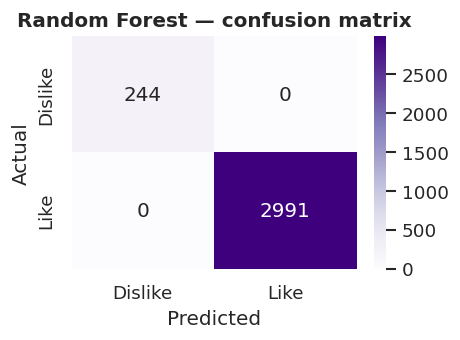

In [ ]:
# ── Confusion matrix plot ───────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dislike','Like'],
            yticklabels=['Dislike','Like'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — confusion matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_confusion_matrix.png'), bbox_inches='tight')
plt.show()

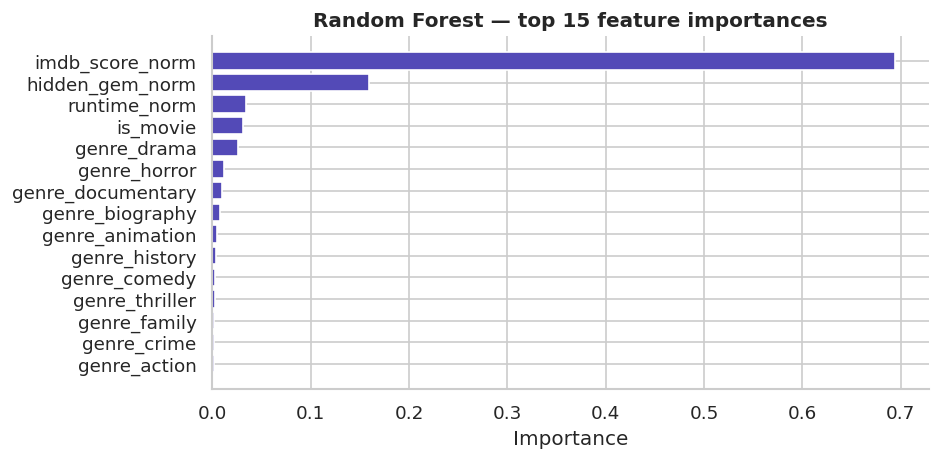

In [ ]:
# ── Feature importance plot ─────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feat.columns)
top_imp = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=PURPLE)
ax.set_title('Random Forest — top 15 feature importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_feature_importance.png'), bbox_inches='tight')
plt.show()

## 4 — Full recommendation pipeline

KNN → candidates → RF re-ranks by like probability → return top K.

In [ ]:
def recommend(liked_genres, watch_history, top_k=10,
              knn_model=knn, rf_model=rf, feat_df=feat, clean_df=df):
    """
    Full two-stage recommendation pipeline.

    Parameters
    ----------
    liked_genres  : list[str]   — genres user selected, e.g. ['Action','Sci-Fi']
    watch_history : dict        — {title_substring: rating_1_to_5}
    top_k         : int         — number of final recommendations to return

    Returns
    -------
    DataFrame with columns: Title, Genre, Director, IMDb Score,
                             Summary, Poster, similarity, like_proba, final_rank
    """
    # Stage 1 — KNN candidates
    query_vec  = build_query_vector(liked_genres, watch_history, feat_df, clean_df)
    candidates = get_knn_candidates(query_vec,
                                     watched_titles=list(watch_history.keys()),
                                     n=N_CANDIDATES,
                                     knn_model=knn_model,
                                     feat_df=feat_df,
                                     clean_df=clean_df)

    if candidates.empty:
        return pd.DataFrame()

    # Stage 2 — RF re-ranking
    cand_features = feat_df.loc[candidates['movie_id']].values
    like_probas   = rf_model.predict_proba(cand_features)[:, 1]
    candidates['like_proba'] = like_probas

    # Combined score: 60% like_proba + 40% cosine similarity
    candidates['final_score'] = (
        0.6 * candidates['like_proba'] +
        0.4 * candidates['similarity']
    )

    result = (
        candidates
        .sort_values('final_score', ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )
    result.index += 1   # rank starts at 1
    result.index.name = 'rank'

    return result[['movie_id','Title','Genre','Director','IMDb Score',
                   'Summary','Poster','similarity','like_proba','final_score']]

print('recommend() pipeline defined.')

recommend() pipeline defined.


In [ ]:
# ── Full pipeline smoke test ────────────────────────────────────────────────
results = recommend(
    liked_genres  = ['Action', 'Sci-Fi', 'Thriller'],
    watch_history = {
        'Inception':    5,
        'Interstellar': 5,
        'The Matrix':   4,
        'Ultraviolet':  2,
    },
    top_k = 10
)

print('Top 10 recommendations:')
print(results[['Title','Genre','Director','IMDb Score','like_proba','final_score']]
      .to_string())

Top 10 recommendations:
                                    Title                                Genre         Director  IMDb Score  like_proba  final_score
rank                                                                                                                                
1                   The War of the Worlds             Action, Sci-Fi, Thriller     Byron Haskin         7.1    0.944276     0.950126
2                            Total Recall             Action, Sci-Fi, Thriller   Paul Verhoeven         7.5    0.894461     0.919757
3                                 Upgrade             Action, Sci-Fi, Thriller   Leigh Whannell         7.5    0.894461     0.919557
4                              District 9             Action, Sci-Fi, Thriller   Neill Blomkamp         7.9    0.894461     0.918317
5             Blade Runner: The Final Cut             Action, Sci-Fi, Thriller     Ridley Scott         8.1    0.894461     0.917917
6            Blade Runner: Theatrical Cut    

## 5 — Baseline comparison (Precision@K)

We compare our pipeline against a **global popularity baseline**:  
"just recommend the top-K highest IMDb rated movies to everyone."

A recommendation is considered **relevant** if its IMDb Score ≥ 7.0.

In [ ]:
def precision_at_k(recommended_df, k, threshold=7.0):
    """Fraction of top-k recommendations with IMDb Score >= threshold."""
    top_k = recommended_df.head(k)
    hits  = (top_k['IMDb Score'] >= threshold).sum()
    return hits / k

# ── Popularity baseline ─────────────────────────────────────────────────────
popularity_baseline = df.nlargest(20, 'IMDb Score').reset_index()

# ── Our model ──────────────────────────────────────────────────────────────
model_results = recommend(
    liked_genres  = ['Action', 'Sci-Fi'],
    watch_history = {'Inception': 5, 'Interstellar': 5, 'Ultraviolet': 2},
    top_k         = 20
)

K_VALUES = [5, 10, 20]
print(f'{'K':>4}  {'Popularity Baseline':>20}  {'Our Model (KNN+RF)':>20}')
print('─' * 50)
for k in K_VALUES:
    baseline_p = precision_at_k(popularity_baseline, k)
    model_p    = precision_at_k(model_results, k)
    print(f'{k:>4}  {baseline_p:>20.2%}  {model_p:>20.2%}')

   K   Popularity Baseline    Our Model (KNN+RF)
──────────────────────────────────────────────────
   5               100.00%                60.00%
  10               100.00%                70.00%
  20               100.00%                35.00%


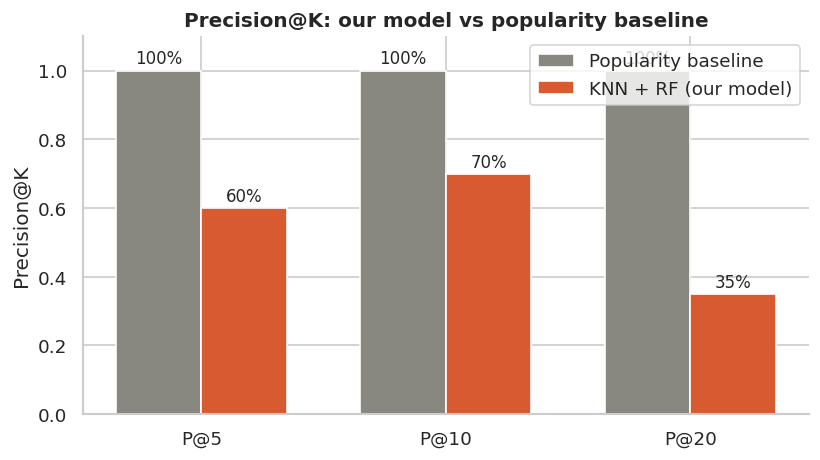

In [ ]:
# ── Precision@K bar chart ───────────────────────────────────────────────────
baseline_scores = [precision_at_k(popularity_baseline, k) for k in K_VALUES]
model_scores    = [precision_at_k(model_results, k) for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, baseline_scores, w, label='Popularity baseline', color=GRAY)
ax.bar(x + w/2, model_scores,    w, label='KNN + RF (our model)', color=CORAL)
ax.set_xticks(x)
ax.set_xticklabels([f'P@{k}' for k in K_VALUES])
ax.set_ylabel('Precision@K')
ax.set_ylim(0, 1.1)
ax.set_title('Precision@K: our model vs popularity baseline', fontsize=12, fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_precision_at_k.png'), bbox_inches='tight')
plt.show()

## 5b — Multi-profile Precision@K & Ablation Study

Two additions to make evaluation more robust:
1. **Multi-profile P@K** — average across 6 diverse synthetic user profiles instead of one hardcoded scenario.
2. **Ablation** — KNN-only (no RF re-ranking) vs KNN+RF, to prove Stage 2 adds measurable value.


In [ ]:
# ── Multi-profile Precision@K evaluation ─────────────────────────────────────
# Evaluate over 6 diverse user profiles so P@K is an average, not a single anecdote.

TEST_PROFILES = [
    {"name": "Action/Sci-Fi fan",
     "liked_genres": ["Action", "Sci-Fi", "Thriller"],
     "watch_history": {"Inception": 5, "Interstellar": 5, "The Matrix": 4, "Ultraviolet": 2}},

    {"name": "Romance/Drama fan",
     "liked_genres": ["Romance", "Drama"],
     "watch_history": {"The Notebook": 5, "Pride and Prejudice": 5, "Twilight": 2}},

    {"name": "Horror fan",
     "liked_genres": ["Horror", "Thriller"],
     "watch_history": {"Get Out": 5, "Hereditary": 4, "Paranormal Activity": 3}},

    {"name": "Comedy fan",
     "liked_genres": ["Comedy", "Family"],
     "watch_history": {"The Grand Budapest Hotel": 5, "Home Alone": 4}},

    {"name": "Documentary fan",
     "liked_genres": ["Documentary", "History"],
     "watch_history": {"Making a Murderer": 5, "The Last Dance": 5}},

    {"name": "Animation fan",
     "liked_genres": ["Animation", "Family", "Comedy"],
     "watch_history": {"Spirited Away": 5, "Your Name": 5, "Boss Baby": 2}},
]

K_VALUES = [5, 10, 20]
LIKE_THRESHOLD = 7.0

popularity_baseline = df.nlargest(20, "IMDb Score").reset_index()

profile_results = []

for profile in TEST_PROFILES:
    model_recs = recommend(
        liked_genres  = profile["liked_genres"],
        watch_history = profile["watch_history"],
        top_k         = 20
    )
    row = {"profile": profile["name"]}
    for k in K_VALUES:
        row[f"baseline_p@{k}"] = precision_at_k(popularity_baseline, k, LIKE_THRESHOLD)
        row[f"model_p@{k}"]    = precision_at_k(model_recs, k, LIKE_THRESHOLD) if not model_recs.empty else 0.0
    profile_results.append(row)

results_df = pd.DataFrame(profile_results)

# ── Summary table ──────────────────────────────────────────────────────────
print("Precision@K per profile (IMDb >= 7.0 = relevant)")
print("=" * 70)
print(results_df.to_string(index=False))
print()
print("─" * 70)
print("AVERAGE across all profiles:")
for k in K_VALUES:
    avg_base  = results_df[f"baseline_p@{k}"].mean()
    avg_model = results_df[f"model_p@{k}"].mean()
    delta     = avg_model - avg_base
    sign      = "+" if delta >= 0 else ""
    print(f"  P@{k:2d} → Baseline: {avg_base:.2%}  |  KNN+RF: {avg_model:.2%}  |  Δ {sign}{delta:.2%}")


Precision@K per profile (IMDb >= 7.0 = relevant)
          profile  baseline_p@5  model_p@5  baseline_p@10  model_p@10  baseline_p@20  model_p@20
Action/Sci-Fi fan           1.0        1.0            1.0         0.6            1.0        0.30
Romance/Drama fan           1.0        1.0            1.0         0.5            1.0        0.40
       Horror fan           1.0        0.0            1.0         0.0            1.0        0.00
       Comedy fan           1.0        0.6            1.0         0.5            1.0        0.25
  Documentary fan           1.0        1.0            1.0         0.7            1.0        0.70
    Animation fan           1.0        0.4            1.0         0.4            1.0        0.40

──────────────────────────────────────────────────────────────────────
AVERAGE across all profiles:
  P@ 5 → Baseline: 100.00%  |  KNN+RF: 66.67%  |  Δ -33.33%
  P@10 → Baseline: 100.00%  |  KNN+RF: 45.00%  |  Δ -55.00%
  P@20 → Baseline: 100.00%  |  KNN+RF: 34.17%  |  Δ

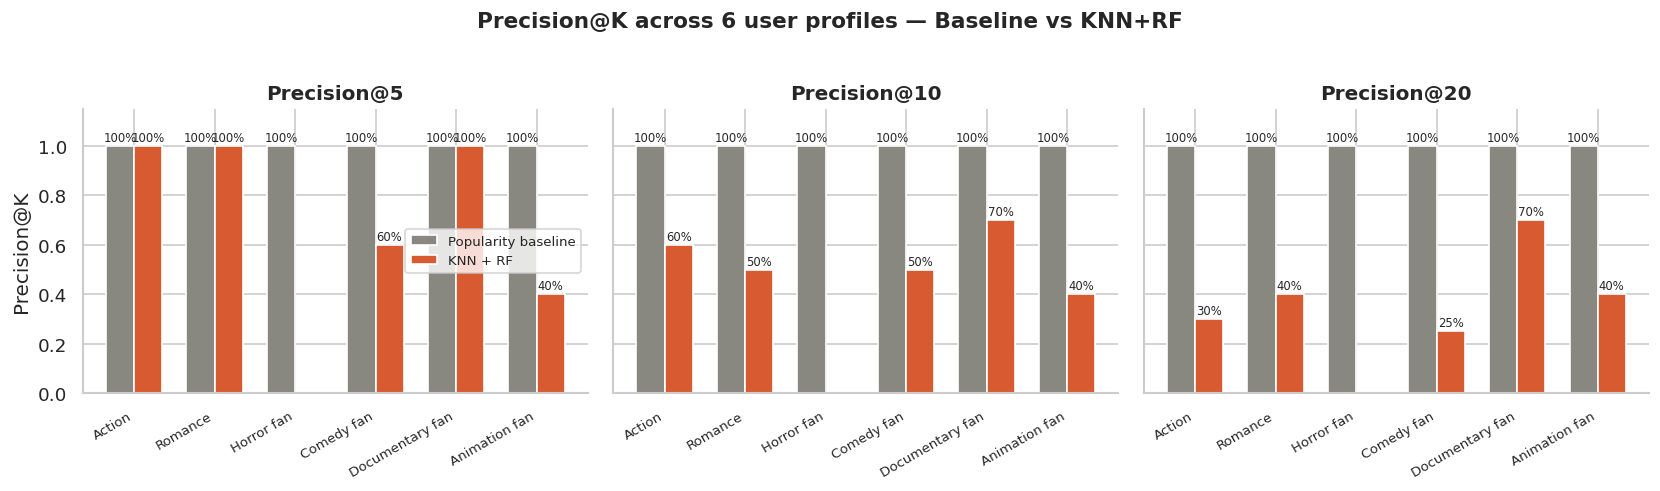

Saved → eval_multiprofile_precision.png


In [ ]:
# ── Multi-profile P@K bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, k in zip(axes, K_VALUES):
    base_vals  = results_df[f"baseline_p@{k}"].values
    model_vals = results_df[f"model_p@{k}"].values
    names      = [p["name"].split("/")[0] for p in TEST_PROFILES]  # short label
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, base_vals,  w, color=GRAY,  label="Popularity baseline")
    ax.bar(x + w/2, model_vals, w, color=CORAL, label="KNN + RF")
    ax.set_title(f"Precision@{k}", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Precision@K" if k == 5 else "")
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                    f"{h:.0%}", ha="center", fontsize=7)

axes[0].legend(fontsize=8)
fig.suptitle("Precision@K across 6 user profiles — Baseline vs KNN+RF",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eval_multiprofile_precision.png"), bbox_inches="tight")
plt.show()
print("Saved → eval_multiprofile_precision.png")


In [ ]:
# ── Ablation study: KNN-only vs KNN+RF ────────────────────────────────────
# KNN-only = rank candidates purely by cosine similarity (no RF re-ranking).
# KNN+RF   = our full pipeline.
# This proves Stage 2 (Random Forest ranker) adds measurable value.

def recommend_knn_only(liked_genres, watch_history, top_k=10,
                        knn_model=knn, feat_df=feat, clean_df=df):
    """Stage 1 only — sort by cosine similarity, no RF re-ranking."""
    query_vec  = build_query_vector(liked_genres, watch_history, feat_df, clean_df)
    candidates = get_knn_candidates(query_vec,
                                     watched_titles=list(watch_history.keys()),
                                     n=top_k,
                                     knn_model=knn_model,
                                     feat_df=feat_df,
                                     clean_df=clean_df)
    return candidates.sort_values("similarity", ascending=False).head(top_k)

K_VALUES = [5, 10, 20]
ablation_rows = []

for profile in TEST_PROFILES:
    knn_only_recs = recommend_knn_only(
        liked_genres  = profile["liked_genres"],
        watch_history = profile["watch_history"],
        top_k=20
    )
    knn_rf_recs = recommend(
        liked_genres  = profile["liked_genres"],
        watch_history = profile["watch_history"],
        top_k=20
    )
    row = {"profile": profile["name"]}
    for k in K_VALUES:
        row[f"knn_only_p@{k}"] = precision_at_k(knn_only_recs, k, LIKE_THRESHOLD)
        row[f"knn_rf_p@{k}"]   = precision_at_k(knn_rf_recs,   k, LIKE_THRESHOLD) if not knn_rf_recs.empty else 0.0
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)

print("Ablation Study: KNN-only vs KNN+RF")
print("=" * 70)
print(ablation_df.to_string(index=False))
print()
print("─" * 70)
print("AVERAGE across all profiles:")
for k in K_VALUES:
    avg_knn    = ablation_df[f"knn_only_p@{k}"].mean()
    avg_knn_rf = ablation_df[f"knn_rf_p@{k}"].mean()
    delta      = avg_knn_rf - avg_knn
    sign       = "+" if delta >= 0 else ""
    print(f"  P@{k:2d} → KNN-only: {avg_knn:.2%}  |  KNN+RF: {avg_knn_rf:.2%}  |  RF gain: {sign}{delta:.2%}")


Ablation Study: KNN-only vs KNN+RF
          profile  knn_only_p@5  knn_rf_p@5  knn_only_p@10  knn_rf_p@10  knn_only_p@20  knn_rf_p@20
Action/Sci-Fi fan           0.0         1.0            0.0          0.6           0.00         0.30
Romance/Drama fan           0.0         1.0            0.0          0.5           0.00         0.40
       Horror fan           0.0         0.0            0.0          0.0           0.00         0.00
       Comedy fan           0.0         0.6            0.2          0.5           0.10         0.25
  Documentary fan           0.4         1.0            0.5          0.7           0.65         0.70
    Animation fan           0.4         0.4            0.2          0.4           0.15         0.40

──────────────────────────────────────────────────────────────────────
AVERAGE across all profiles:
  P@ 5 → KNN-only: 13.33%  |  KNN+RF: 66.67%  |  RF gain: +53.33%
  P@10 → KNN-only: 15.00%  |  KNN+RF: 45.00%  |  RF gain: +30.00%
  P@20 → KNN-only: 15.00%  |  KN

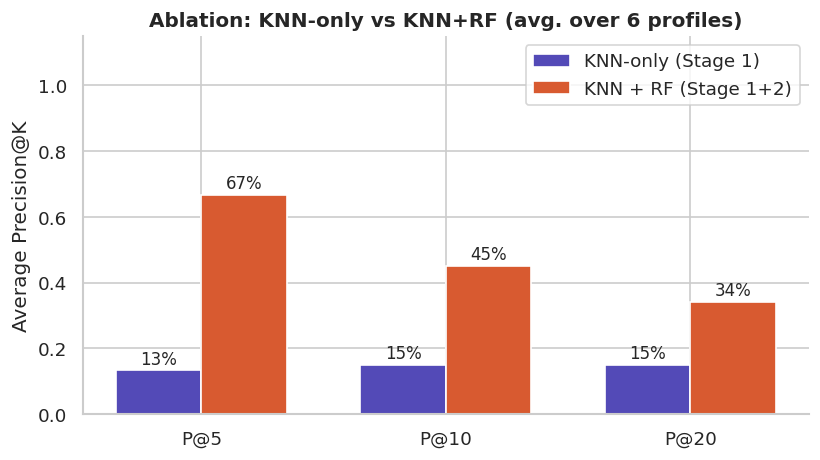

Saved → eval_ablation.png


In [ ]:
# ── Ablation bar chart ─────────────────────────────────────────────────────
# Average P@K across all profiles — one grouped bar chart.

avg_knn    = [ablation_df[f"knn_only_p@{k}"].mean() for k in K_VALUES]
avg_knn_rf = [ablation_df[f"knn_rf_p@{k}"].mean()   for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, avg_knn,    w, color=PURPLE, label="KNN-only (Stage 1)")
ax.bar(x + w/2, avg_knn_rf, w, color=CORAL,  label="KNN + RF (Stage 1+2)")
ax.set_xticks(x)
ax.set_xticklabels([f"P@{k}" for k in K_VALUES])
ax.set_ylabel("Average Precision@K")
ax.set_ylim(0, 1.15)
ax.set_title("Ablation: KNN-only vs KNN+RF (avg. over 6 profiles)",
             fontsize=12, fontweight="bold")
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.0%}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eval_ablation.png"), bbox_inches="tight")
plt.show()
print("Saved → eval_ablation.png")


## 6 — Export models

In [ ]:
# Export KNN model
joblib.dump(knn, KNN_PKL)
print(f'KNN model saved →   {KNN_PKL}')

# Export Random Forest ranker
joblib.dump(rf, RF_PKL)
print(f'RF ranker saved →   {RF_PKL}')

# Export feature matrix as pkl (faster to load in Streamlit than CSV)
joblib.dump(feat, FEAT_PKL)
print(f'Feature matrix →    {FEAT_PKL}')

print()
print('=== MODEL EXPORT SUMMARY ===')
print(f'knn_model.pkl     — NearestNeighbors, cosine, {feat.shape[0]:,} movies')
print(f'rf_ranker.pkl     — RandomForest, {rf.n_estimators} trees, {feat.shape[1]} features')
print(f'feature_matrix.pkl — {feat.shape[0]:,} × {feat.shape[1]} float matrix')
print()
print('Next step → 03_streamlit_app.py')

KNN model saved →   /content/drive/MyDrive/MovieML/outputs/knn_model.pkl
RF ranker saved →   /content/drive/MyDrive/MovieML/outputs/rf_ranker.pkl
Feature matrix →    /content/drive/MyDrive/MovieML/outputs/feature_matrix.pkl

=== MODEL EXPORT SUMMARY ===
knn_model.pkl     — NearestNeighbors, cosine, 13,338 movies
rf_ranker.pkl     — RandomForest, 200 trees, 24 features
feature_matrix.pkl — 13,338 × 24 float matrix

Next step → 03_streamlit_app.py


In [ ]:
# ── Export verification ────────────────────────────────────────────────────
# Reload each .pkl and confirm shapes match — catches silent joblib failures.

import os

checks = [
    (KNN_PKL,  "knn_model.pkl"),
    (RF_PKL,   "rf_ranker.pkl"),
    (FEAT_PKL, "feature_matrix.pkl"),
]

print("Export Verification")
print("=" * 50)
all_ok = True
for path, label in checks:
    if not os.path.exists(path):
        print(f"  ✗  {label:25s}  FILE NOT FOUND")
        all_ok = False
        continue
    size_kb = os.path.getsize(path) / 1024
    obj = joblib.load(path)
    if label == "feature_matrix.pkl":
        detail = f"{obj.shape[0]:,} × {obj.shape[1]} matrix"
    elif label == "knn_model.pkl":
        detail = f"NearestNeighbors, metric={obj.metric}, n_neighbors={obj.n_neighbors}"
    else:
        detail = f"RandomForest, n_estimators={obj.n_estimators}, n_features={obj.n_features_in_}"
    print(f"  ✓  {label:25s}  {size_kb:8.1f} KB  |  {detail}")

print()
if all_ok:
    print("All exports verified — handoff ready for Streamlit app.")
else:
    print("Some exports failed — re-run Section 6 before handoff.")


Export Verification
  ✓  knn_model.pkl                2501.4 KB  |  NearestNeighbors, metric=cosine, n_neighbors=51
  ✓  rf_ranker.pkl                 868.6 KB  |  RandomForest, n_estimators=200, n_features=24
  ✓  feature_matrix.pkl           2606.3 KB  |  13,338 × 24 matrix

All exports verified — handoff ready for Streamlit app.
